# E-Commerce Sales & Customer Analytics — Exploratory Data Analysis

This notebook walks through data cleaning, EDA, KPI calculation, and
customer segmentation for the E-Commerce Sales & Customer Analytics
Dashboard project. It mirrors the logic in `src/data_cleaning.py`,
`src/analysis.py`, and `src/rfm_analysis.py` step by step, with charts,
so the reasoning behind the dashboard is visible and reviewable.


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df_raw = pd.read_csv('../data/ecommerce.csv')
df_raw.shape

(12060, 14)

## 1. Initial Inspection

In [2]:
df_raw.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Category,Sub_Category,Product,Sales,Quantity,Discount,Profit,Region,City,Payment_Mode
0,ORD-003885,2023-01-16,CUST-01918,Vihaan Bose,Electronics,Smartphones,Smartphones - 387,"59,151.04",1,0.00,804.01,West,Pune,UPI
1,ORD-010196,2023-01-09,CUST-00538,Priya Gupta,Electronics,Laptops,Laptops - 857,"179,939.94",3,0.00,"16,112.74",South,Hyderabad,UPI
2,ORD-005035,2024-01-16,CUST-02782,Nikhil Verma,Beauty & Personal Care,Skincare,Skincare - 707,"2,201.10",1,0.05,790.95,East,Kolkata,UPI
3,ORD-002639,2023-09-10,CUST-02867,Pooja Reddy,Books & Stationery,Art Supplies,Art Supplies - 714,"2,136.18",1,0.00,378.06,South,Bengaluru,Debit Card
4,ORD-009203,2023-02-19,CUST-00596,Diya Kumar,Electronics,Accessories,Accessories - 526,"56,334.17",1,0.05,"4,601.45",East,Patna,UPI


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 12060 entries, 0 to 12059
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       12060 non-null  str    
 1   Order_Date     12060 non-null  str    
 2   Customer_ID    12060 non-null  str    
 3   Customer_Name  12060 non-null  str    
 4   Category       12060 non-null  str    
 5   Sub_Category   12060 non-null  str    
 6   Product        12060 non-null  str    
 7   Sales          12060 non-null  float64
 8   Quantity       12060 non-null  int64  
 9   Discount       11816 non-null  float64
 10  Profit         12060 non-null  float64
 11  Region         12060 non-null  str    
 12  City           11880 non-null  str    
 13  Payment_Mode   11940 non-null  str    
dtypes: float64(3), int64(1), str(10)
memory usage: 1.3 MB


In [4]:
print('Missing values:')
print(df_raw.isna().sum()[df_raw.isna().sum() > 0])
print('\nExact duplicate rows:', df_raw.duplicated().sum())

Missing values:
Discount        244
City            180
Payment_Mode    120
dtype: int64

Exact duplicate rows: 56


## 2. Data Cleaning

Cleaning logic lives in `src/data_cleaning.py` so the dashboard app and
this notebook always use identical logic. We import and run it here.

In [5]:
from data_cleaning import clean_pipeline

df = clean_pipeline(raw_path='../data/ecommerce.csv')
df.head()

Loading raw data...
Parsing dates (handles mixed date formats)...


Removing exact duplicate rows...
  Removed 56 duplicate rows
Standardizing text columns...
Handling missing values...
Fixing data types...
Detecting & capping outliers...
  Capped 1145 outliers in 'Sales' to range [0.00, 41346.91]
Engineering features (Year, Month, Profit_Margin, etc.)...

--- Cleaning Summary ---
Rows before: 12060 | Rows after: 12004
Missing values found (pre-clean):
Discount        240
City            180
Payment_Mode    120
dtype: int64
Final shape: (12004, 21)


,Order_ID,Order_Date,Customer_ID,Customer_Name,Category,Sub_Category,Product,Sales,Quantity,Discount,...,Region,City,Payment_Mode,Year,Month,Month_Name,Quarter,Year_Month,Profit_Margin,Revenue_per_Unit
0,ORD-003885,2023-01-16,CUST-01918,Vihaan Bose,Electronics,Smartphones,Smartphones - 387,"41,346.91",1,0.00,...,West,Pune,UPI,2023,1,Jan,1,2023-01,0.02,"41,346.91"
1,ORD-010196,2023-01-09,CUST-00538,Priya Gupta,Electronics,Laptops,Laptops - 857,"41,346.91",3,0.00,...,South,Hyderabad,UPI,2023,1,Jan,1,2023-01,0.39,"13,782.30"
2,ORD-005035,2024-01-16,CUST-02782,Nikhil Verma,Beauty & Personal Care,Skincare,Skincare - 707,"2,201.10",1,0.05,...,East,Kolkata,UPI,2024,1,Jan,1,2024-01,0.36,"2,201.10"
3,ORD-002639,2023-09-10,CUST-02867,Pooja Reddy,Books & Stationery,Art Supplies,Art Supplies - 714,"2,136.18",1,0.00,...,South,Bengaluru,Debit Card,2023,9,Sep,3,2023-09,0.18,"2,136.18"
4,ORD-009203,2023-02-19,CUST-00596,Diya Kumar,Electronics,Accessories,Accessories - 526,"41,346.91",1,0.05,...,East,Patna,UPI,2023,2,Feb,1,2023-02,0.11,"41,346.91"


## 3. Univariate & Distribution Checks

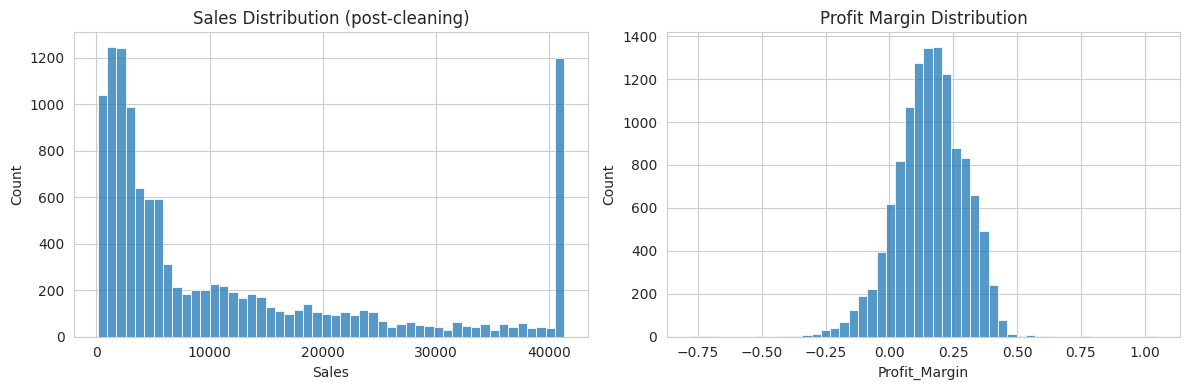

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Sales'], bins=50, ax=axes[0])
axes[0].set_title('Sales Distribution (post-cleaning)')
sns.histplot(df['Profit_Margin'], bins=50, ax=axes[1])
axes[1].set_title('Profit Margin Distribution')
plt.tight_layout()
plt.show()

## 4. Monthly Revenue & Profit Trend

/tmp/ipykernel_591/3682734364.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(trend['Year_Month'], rotation=90)


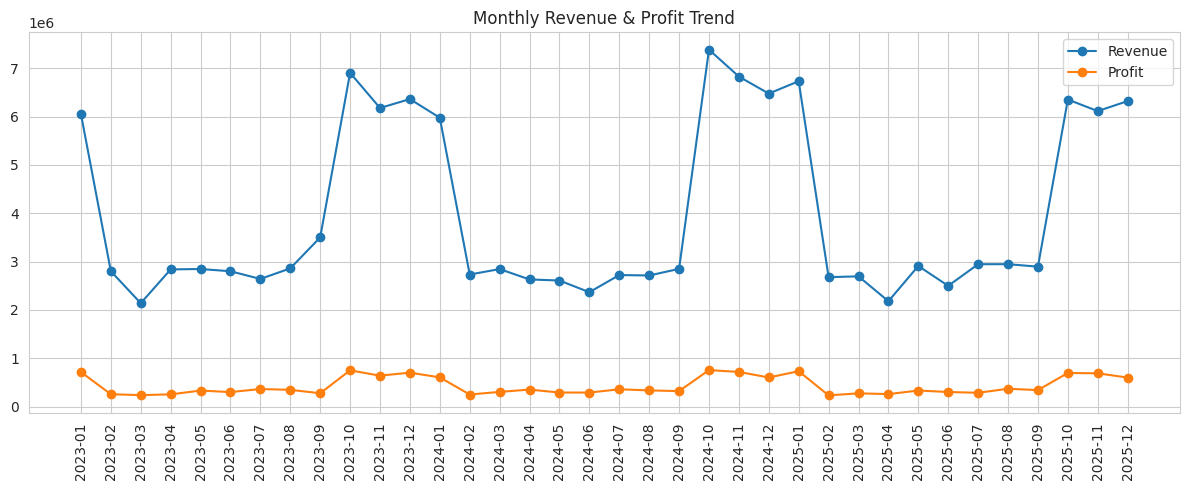

In [7]:
from analysis import monthly_trend

trend = monthly_trend(df)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(trend['Year_Month'], trend['Revenue'], marker='o', label='Revenue')
ax.plot(trend['Year_Month'], trend['Profit'], marker='o', label='Profit')
ax.set_xticklabels(trend['Year_Month'], rotation=90)
ax.legend()
ax.set_title('Monthly Revenue & Profit Trend')
plt.tight_layout()
plt.show()

## 5. Category & Region Performance

,Category,Revenue,Profit,Orders,Units,Profit_Margin_Pct
0,Electronics,"80,706,758.33","5,420,657.61",2836,3430,6.72
1,Home & Kitchen,"33,687,950.50","4,662,204.10",2209,2745,13.84
2,Sports & Outdoors,"12,241,824.63","1,437,547.14",1381,1655,11.74
3,Fashion,"10,536,348.40","2,426,922.86",2624,3245,23.03
4,Beauty & Personal Care,"4,543,373.40","1,326,592.05",1982,2463,29.20
5,Books & Stationery,"1,583,439.29","140,700.59",968,1201,8.89


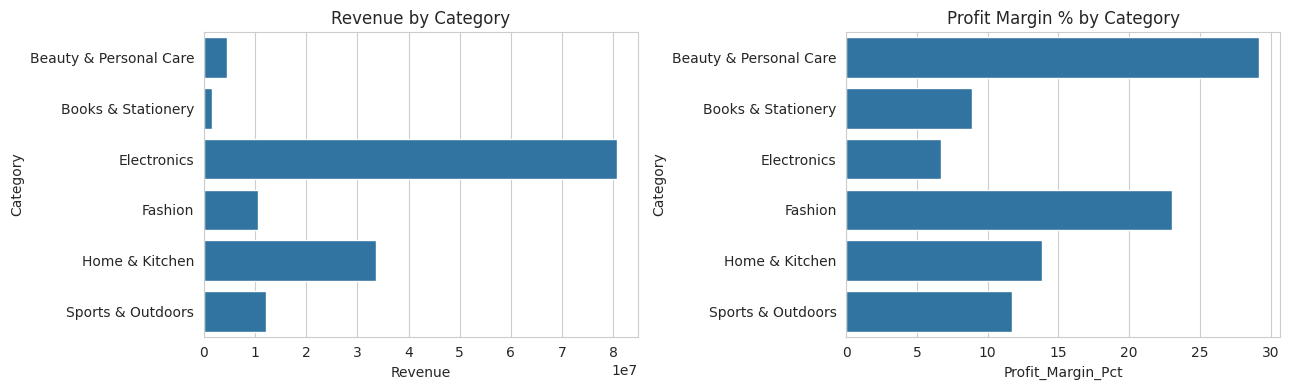

In [8]:
from analysis import category_performance, region_performance

cat_perf = category_performance(df)
display(cat_perf)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=cat_perf, x='Revenue', y='Category', ax=axes[0])
axes[0].set_title('Revenue by Category')
sns.barplot(data=cat_perf, x='Profit_Margin_Pct', y='Category', ax=axes[1])
axes[1].set_title('Profit Margin % by Category')
plt.tight_layout()
plt.show()

,Region,Revenue,Profit,Orders
0,North,"41,258,698.46","4,375,271.39",3507
1,South,"40,297,160.76","4,259,363.69",3286
2,West,"35,147,335.30","3,752,429.60",2945
3,East,"26,596,500.03","3,027,559.67",2262


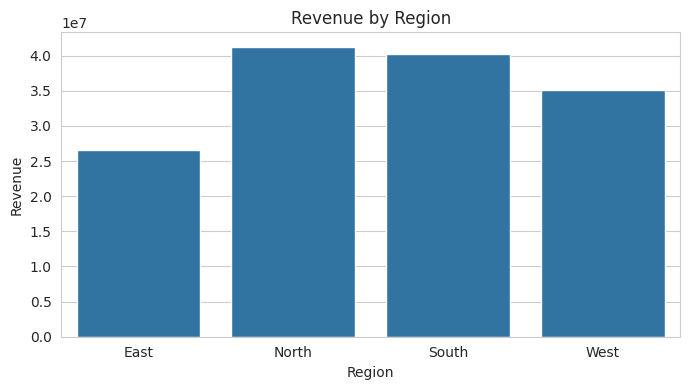

In [9]:
reg_perf = region_performance(df)
display(reg_perf)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=reg_perf, x='Region', y='Revenue', ax=ax)
ax.set_title('Revenue by Region')
plt.tight_layout()
plt.show()

## 6. Discount vs Profit Margin

Does higher discount correlate with lower profit margin?

Correlation between Discount and Profit Margin: -0.663


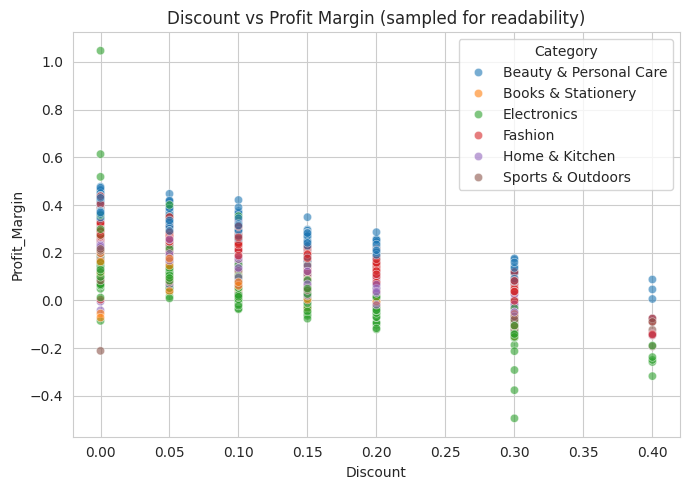

In [10]:
corr = df['Discount'].corr(df['Profit_Margin'])
print(f'Correlation between Discount and Profit Margin: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df.sample(1500, random_state=1), x='Discount', y='Profit_Margin',
                 hue='Category', alpha=0.6, ax=ax)
ax.set_title('Discount vs Profit Margin (sampled for readability)')
plt.tight_layout()
plt.show()

## 7. Customer-Level KPIs & RFM Segmentation

In [11]:
from analysis import compute_kpis
from rfm_analysis import calculate_rfm, segment_summary

kpis = compute_kpis(df)
kpis

{'total_revenue': 143299694.55,
 'total_profit': 15414624.35,
 'total_orders': 12000,
 'total_units_sold': 14739,
 'average_order_value': 11941.64,
 'profit_margin_pct': 10.76,
 'total_customers': 2166,
 'repeat_customers': 1406,
 'repeat_customer_rate_pct': 64.91,
 'avg_customer_lifetime_value_approx': 7116.63}

,Segment,Customers,Avg_Recency_Days,Avg_Frequency,Total_Monetary,Pct_of_Customers,Pct_of_Revenue
0,Champions,462,42.89,17.25,"99,191,001.80",21.30,69.20
1,Loyal Customers,393,162.82,4.53,"20,868,976.75",18.10,14.60
2,At Risk,210,509.43,3.29,"10,185,552.05",9.70,7.10
3,Needs Attention,535,402.95,1.74,"8,819,620.68",24.70,6.20
4,Potential Loyalists,159,55.89,1.23,"2,268,503.31",7.30,1.60
5,Lost Customers,407,687.85,1.07,"1,966,039.96",18.80,1.40


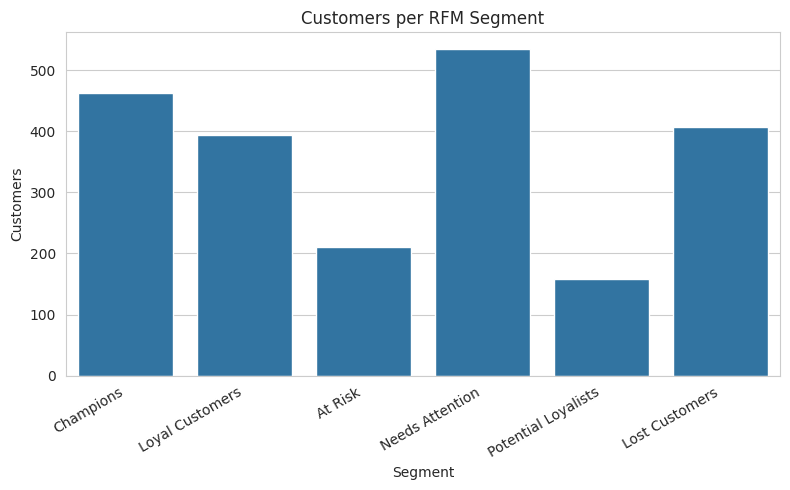

In [12]:
rfm = calculate_rfm(df)
summary = segment_summary(rfm)
display(summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=summary, x='Segment', y='Customers', ax=ax)
ax.set_title('Customers per RFM Segment')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Auto-Generated Key Business Insights

In [13]:
from analysis import generate_insights

for i, ins in enumerate(generate_insights(df), 1):
    print(f'{i}. {ins}')

1. Electronics is the top revenue-generating category, contributing ₹80,706,758 (56.3% of total revenue).
2. Electronics has the weakest profit margin at 6.7%, despite generating ₹80,706,758 in revenue.
3. North is the strongest region by revenue (₹41,258,698), while East underperforms at ₹26,596,500.
4. 'Laptops' (Electronics) generates above-median revenue (₹16,847,392) but only a 5.7% profit margin — a candidate for pricing or discount review.
5. Discount rate and profit margin show a negative correlation (r = -0.663) — higher discounts are associated with lower margins.
6. 2024-10 was the strongest month (₹7,385,407 in revenue), while 2023-03 was the weakest (₹2,137,910).
7. Repeat customers make up 64.9% of the customer base but are the main driver of long-term value (avg. customer lifetime profit ≈ ₹7,117).


## 9. Save Cleaned Outputs for the Dashboard / SQL Layer

In [14]:
df.to_csv('../data/ecommerce_clean.csv', index=False)
rfm.to_csv('../data/rfm_segments.csv', index=False)
print('Saved cleaned dataset and RFM segments for use by app/app.py and the SQL database.')

Saved cleaned dataset and RFM segments for use by app/app.py and the SQL database.
